In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, classification_report,
                             ConfusionMatrixDisplay)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("diamonds.csv")
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")
df.head()

📐 Boyut : 53,940 satır × 10 sütun


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print("❓ Eksik Değer Analizi:")
print(df.isnull().sum())
print(f"\n🔁 Tamamen aynı satır sayısı: {df.duplicated().sum()}")

❓ Eksik Değer Analizi:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

🔁 Tamamen aynı satır sayısı: 146


In [4]:
print("📊 İstatistiksel Özet:")
df.describe().round(2)

📊 İstatistiksel Özet:


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [5]:
print("🏷️  Kesim Kalitesi (cut) Dağılımı:")
print(df["cut"].value_counts())
print(f"\nEn büyük sınıf oranı: %{df['cut'].value_counts(normalize=True).max()*100:.1f}"
      "  <- sınıflandırmada taban çizgimiz bu olacak")

🏷️  Kesim Kalitesi (cut) Dağılımı:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

En büyük sınıf oranı: %40.0  <- sınıflandırmada taban çizgimiz bu olacak


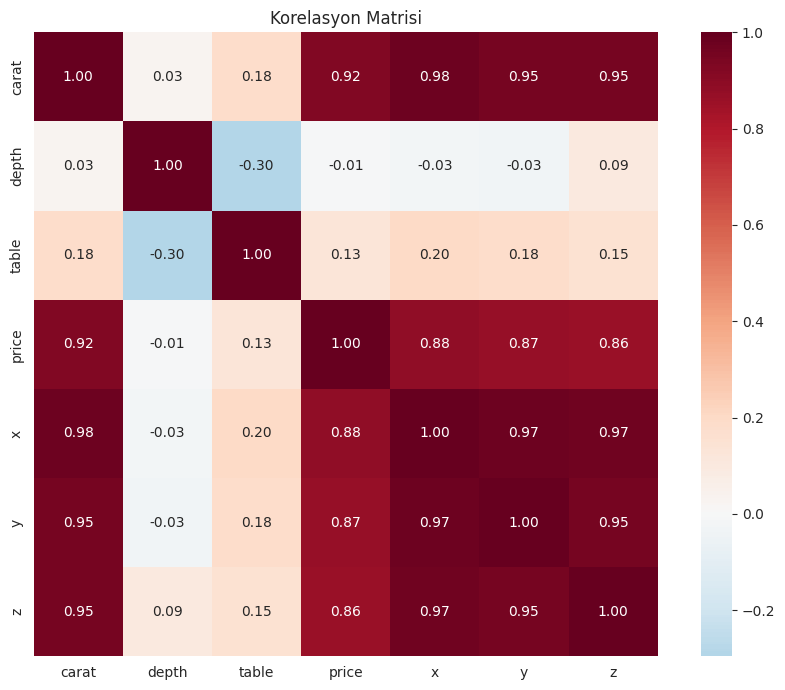

In [6]:
# Korelasyon matrisi (sayısal değişkenler)
sayisal = df.select_dtypes(include=[np.number])

plt.figure(figsize=(9, 7))
sns.heatmap(sayisal.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

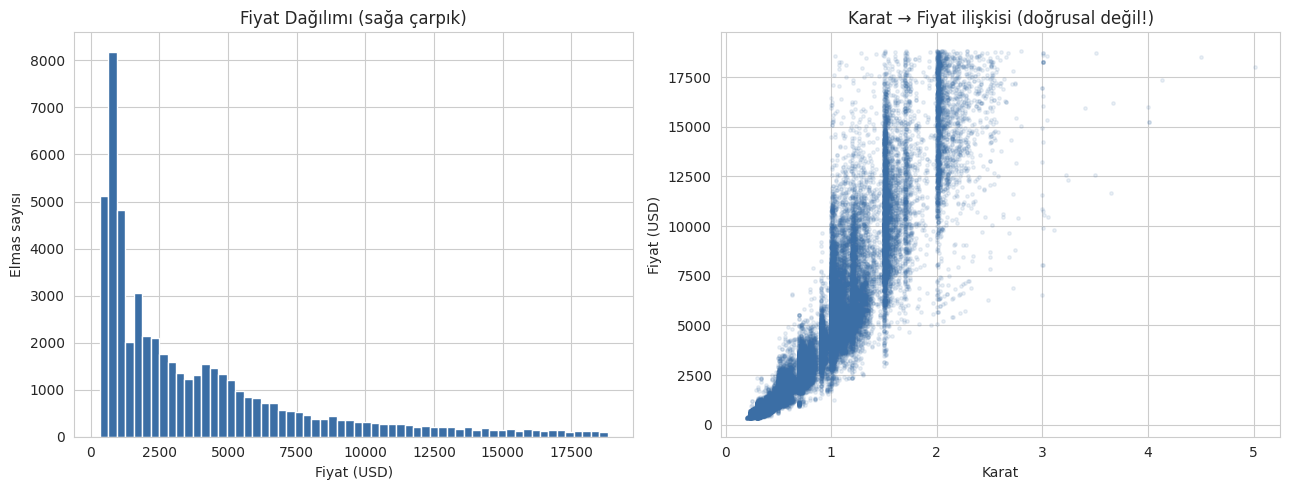

In [7]:
# Hedef değişken dağılımı: fiyat
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["price"], bins=60, color="#3b6ea5", edgecolor="white")
axes[0].set_xlabel("Fiyat (USD)"); axes[0].set_ylabel("Elmas sayısı")
axes[0].set_title("Fiyat Dağılımı (sağa çarpık)")

axes[1].scatter(df["carat"], df["price"], alpha=0.1, s=6, color="#3b6ea5")
axes[1].set_xlabel("Karat"); axes[1].set_ylabel("Fiyat (USD)")
axes[1].set_title("Karat → Fiyat ilişkisi (doğrusal değil!)")

plt.tight_layout()
plt.show()

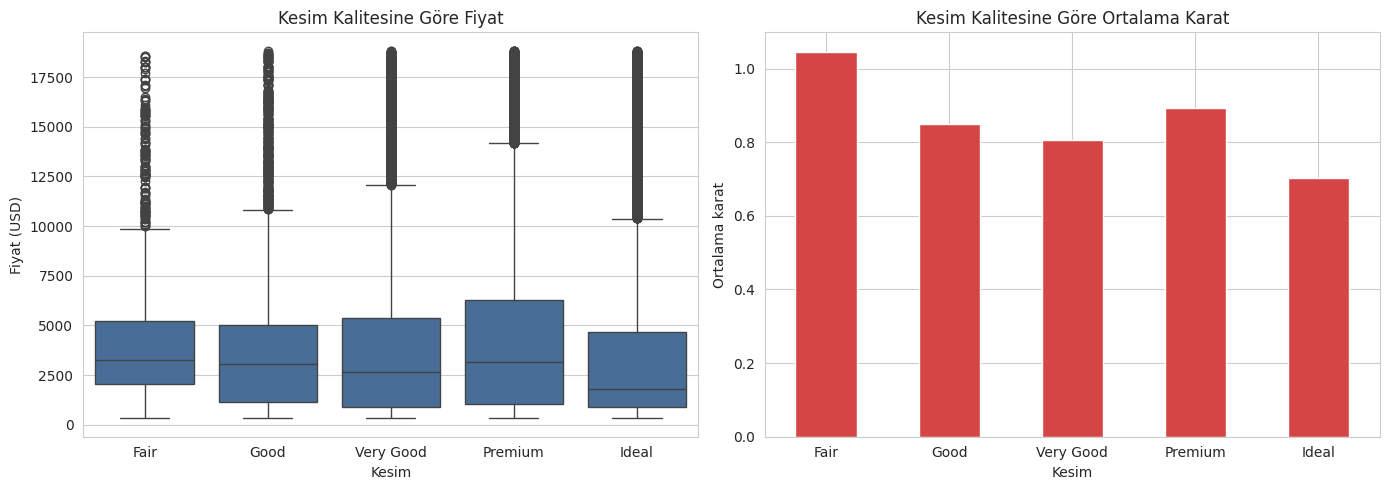

In [8]:
# Kesim kalitesine göre fiyat ve karat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sira = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

sns.boxplot(data=df, x="cut", y="price", order=sira, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Kesim Kalitesine Göre Fiyat")
axes[0].set_xlabel("Kesim"); axes[0].set_ylabel("Fiyat (USD)")

df.groupby("cut")["carat"].mean().reindex(sira).plot(kind="bar", ax=axes[1], color="#d64545")
axes[1].set_title("Kesim Kalitesine Göre Ortalama Karat")
axes[1].set_xlabel("Kesim"); axes[1].set_ylabel("Ortalama karat")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [9]:
df_clean = df.copy()

# ── 1) Duplicate kayıtlar ─────────────────────────────────────────────
oncesi = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicate temizliği: {oncesi:,} → {len(df_clean):,} satır")

# ── 2) Fiziksel olarak imkânsız boyutlar ──────────────────────────────
imkansiz = ((df_clean[["x", "y", "z"]] == 0).any(axis=1) |
            (df_clean["y"] > 20) | (df_clean["z"] > 20))
print(f"İmkânsız boyutlu satır: {imkansiz.sum()}")
df_clean = df_clean[~imkansiz].reset_index(drop=True)
print(f"Temizlik sonrası: {len(df_clean):,} satır")

Duplicate temizliği: 53,940 → 53,794 satır
İmkânsız boyutlu satır: 22
Temizlik sonrası: 53,772 satır


In [10]:
# ── 3) Kategorik değişkenlerin kodlanması ─────────────────────────────
# color ve clarity SIRALI (ordinal) değişkenler -> sıralamayı koruyan kodlama kullanıyoruz.
# One-hot yapsaydık "D, E'den iyidir" bilgisini kaybederdik!

renk_sirasi    = ["J", "I", "H", "G", "F", "E", "D"]            # kötüden iyiye
berraklik_sirasi = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
kesim_sirasi   = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

df_clean["color_kod"]   = df_clean["color"].map({v: i for i, v in enumerate(renk_sirasi)})
df_clean["clarity_kod"] = df_clean["clarity"].map({v: i for i, v in enumerate(berraklik_sirasi)})
df_clean["cut_kod"]     = df_clean["cut"].map({v: i for i, v in enumerate(kesim_sirasi)})

df_clean[["color", "color_kod", "clarity", "clarity_kod", "cut", "cut_kod"]].head()

,color,color_kod,clarity,clarity_kod,cut,cut_kod
0,E,5,SI2,1,Ideal,4
1,E,5,SI1,2,Premium,3
2,E,5,VS1,4,Good,1
3,I,1,VS2,3,Premium,3
4,J,0,SI2,1,Good,1


In [11]:
# Özellik / hedef ayrımı
ozellikler_reg = ["carat", "cut_kod", "color_kod", "clarity_kod", "depth", "table", "x", "y", "z"]
X_reg = df_clean[ozellikler_reg]
y_reg = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Eğitim: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Eğitim: 43,017 | Test: 10,755


In [12]:
rf_reg = RandomForestRegressor(
    n_estimators=100,      # 100 karar ağacı
    max_depth=None,        # ağaçlar tam derinliğe kadar büyüsün
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(X_train, y_train)
print("Model eğitildi ✓")

Model eğitildi ✓


In [13]:
y_pred = rf_reg.predict(X_test)

print("📈 REGRESYON SONUÇLARI")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred):,.0f} USD")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} USD")
print(f"\n  (Ortalama elmas fiyatı: {y_test.mean():,.0f} USD)")

📈 REGRESYON SONUÇLARI
  R²   : 0.9823
  MAE  : 264 USD
  RMSE : 524 USD

  (Ortalama elmas fiyatı: 3,902 USD)


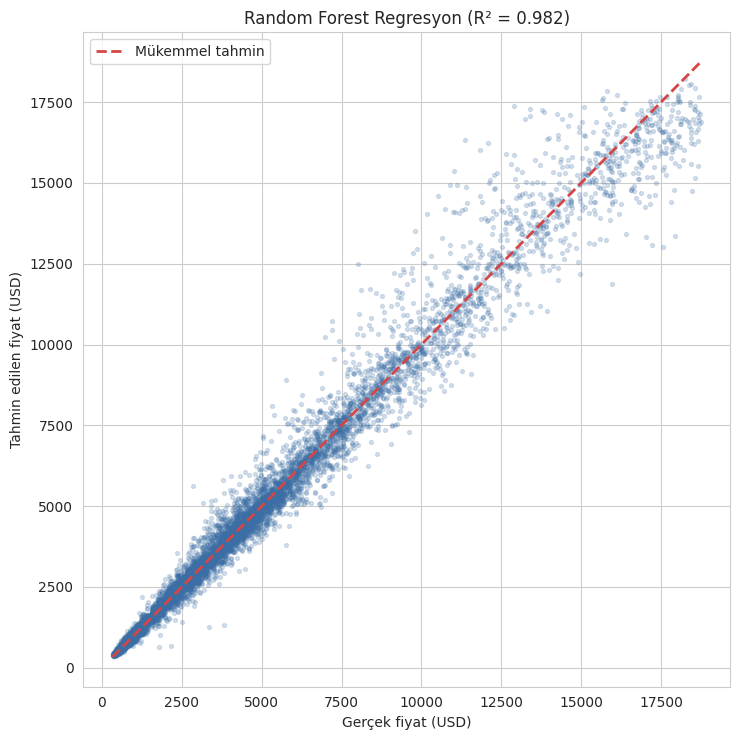

In [14]:
# Gerçek vs Tahmin
plt.figure(figsize=(7.5, 7.5))
plt.scatter(y_test, y_pred, alpha=0.2, s=8, color="#3b6ea5")
kenar = [y_test.min(), y_test.max()]
plt.plot(kenar, kenar, "--", color="#d64545", linewidth=2, label="Mükemmel tahmin")
plt.xlabel("Gerçek fiyat (USD)"); plt.ylabel("Tahmin edilen fiyat (USD)")
plt.title(f"Random Forest Regresyon (R² = {r2_score(y_test, y_pred):.3f})")
plt.legend()
plt.tight_layout()
plt.show()

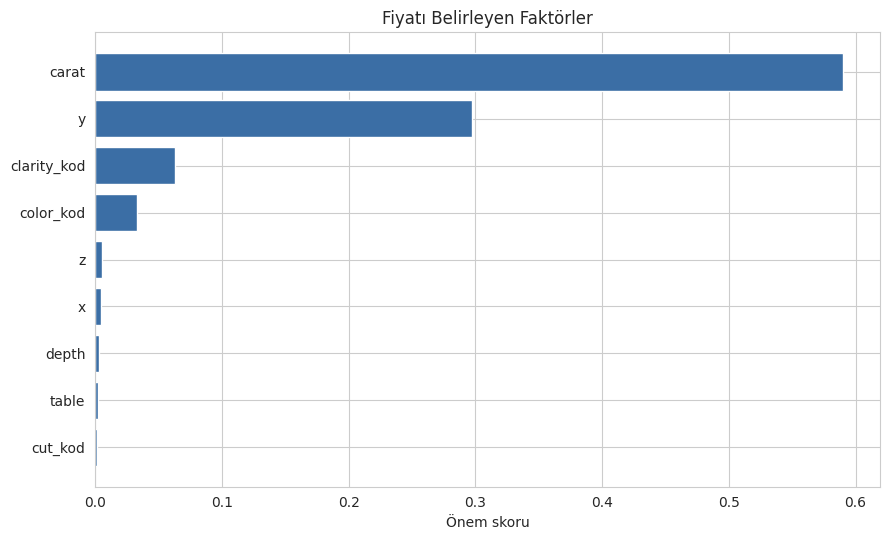

    Ozellik   Onem
      carat 0.5898
          y 0.2969
clarity_kod 0.0633
  color_kod 0.0327
          z 0.0053
          x 0.0048
      depth 0.0030
      table 0.0023
    cut_kod 0.0018


In [15]:
# Özellik önem grafiği — Random Forest'ın en güçlü yanı
onem_reg = pd.DataFrame({
    "Ozellik": ozellikler_reg,
    "Onem": rf_reg.feature_importances_,
}).sort_values("Onem", ascending=True)

plt.figure(figsize=(9, 5.5))
plt.barh(onem_reg["Ozellik"], onem_reg["Onem"], color="#3b6ea5")
plt.xlabel("Önem skoru")
plt.title("Fiyatı Belirleyen Faktörler")
plt.tight_layout()
plt.show()

print(onem_reg.sort_values("Onem", ascending=False).round(4).to_string(index=False))

In [16]:
# ⚠️ Örneklem SADECE eğitim setinden alınmalı!
# df_clean'den rastgele örnek alsaydık içine test satırları karışır, model test verisini
# görmüş olurdu (veri sızıntısı) ve skor haksız yere yüksek çıkardı.
ara_idx = X_train.sample(n=10000, random_state=42).index
X_ara = X_train.loc[ara_idx]
y_ara = y_train.loc[ara_idx]

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, None],
    "min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring="r2", verbose=1
)
grid_search.fit(X_ara, y_ara)

print("\n🏆 En iyi parametreler:", grid_search.best_params_)
print(f"En iyi CV R²: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits



🏆 En iyi parametreler: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
En iyi CV R²: 0.9762


In [17]:
# En iyi model test setinde
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"Varsayılan model (43.000 satırla eğitildi)  R²: {r2_score(y_test, y_pred):.4f}")
print(f"Optimize model  (10.000 satırla eğitildi)   R²: {r2_score(y_test, y_pred_best):.4f}")
print("\nNot: Random Forest varsayılan ayarlarıyla zaten güçlüdür; hiperparametre ayarı")
print("genelde küçük iyileşmeler sağlar. Buradaki fark büyük ölçüde veri miktarından geliyor.")

Varsayılan model (43.000 satırla eğitildi)  R²: 0.9823
Optimize model  (10.000 satırla eğitildi)   R²: 0.9789

Not: Random Forest varsayılan ayarlarıyla zaten güçlüdür; hiperparametre ayarı
genelde küçük iyileşmeler sağlar. Buradaki fark büyük ölçüde veri miktarından geliyor.


In [18]:
# ⚠️ cut_kod özellik listesinden ÇIKARILMALI - hedefin ta kendisi (veri sızıntısı olurdu!)
ozellikler_clf = ["carat", "color_kod", "clarity_kod", "depth", "table", "price", "x", "y", "z"]
X_clf = df_clean[ozellikler_clf]
y_clf = df_clean["cut"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f"Eğitim: {X_train_clf.shape[0]:,} | Test: {X_test_clf.shape[0]:,}")
print(f"\nTaban çizgisi (hep en sık sınıfı söylemek): "
      f"%{y_clf.value_counts(normalize=True).max()*100:.1f}")

Eğitim: 43,017 | Test: 10,755

Taban çizgisi (hep en sık sınıfı söylemek): %40.0


In [19]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",   # sınıflar dengesiz (Ideal 21bin, Fair 1.6bin)
)
rf_clf.fit(X_train_clf, y_train_clf)
print("Model eğitildi ✓")

Model eğitildi ✓


In [20]:
y_pred_clf = rf_clf.predict(X_test_clf)

print(f"🏷️  Doğruluk: {accuracy_score(y_test_clf, y_pred_clf):.4f}\n")
print(classification_report(y_test_clf, y_pred_clf))

🏷️  Doğruluk: 0.7868

              precision    recall  f1-score   support

        Fair       0.90      0.88      0.89       319
        Good       0.82      0.71      0.76       978
       Ideal       0.82      0.91      0.87      4297
     Premium       0.77      0.81      0.79      2747
   Very Good       0.68      0.55      0.61      2414

    accuracy                           0.79     10755
   macro avg       0.80      0.77      0.78     10755
weighted avg       0.78      0.79      0.78     10755



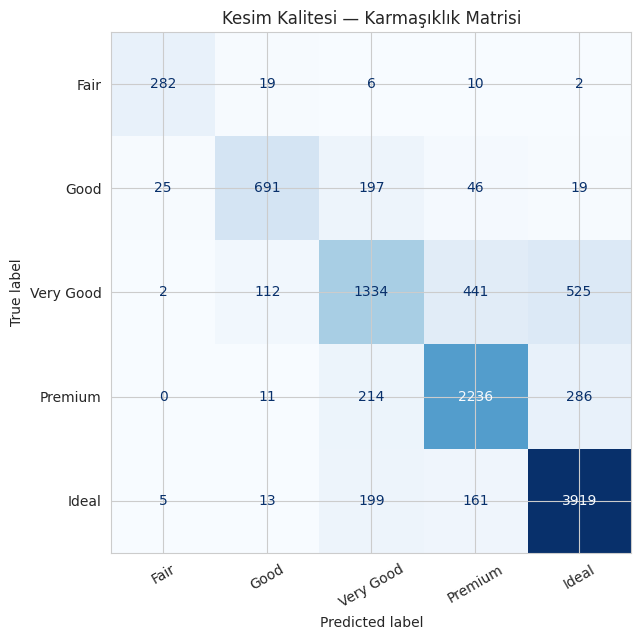

In [21]:
# Karmaşıklık matrisi
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay.from_estimator(
    rf_clf, X_test_clf, y_test_clf,
    labels=kesim_sirasi, cmap="Blues", ax=ax, colorbar=False
)
plt.title("Kesim Kalitesi — Karmaşıklık Matrisi")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

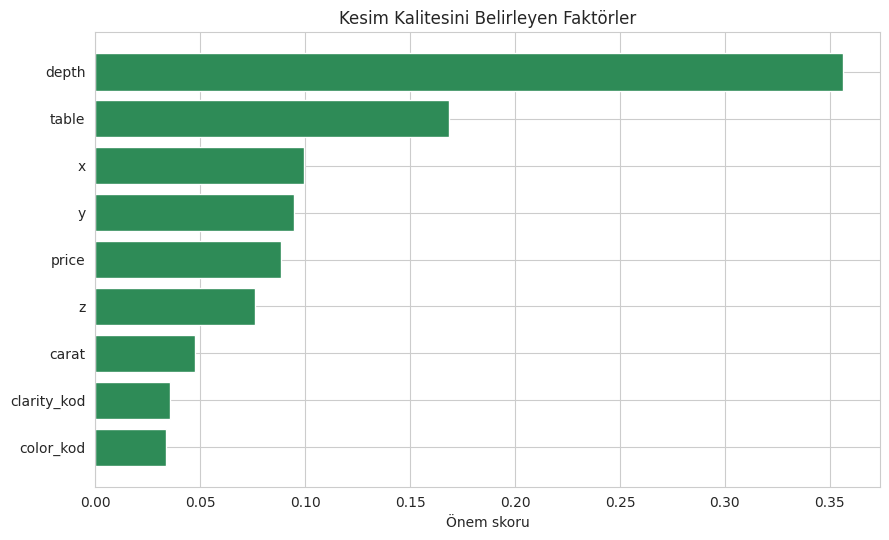

    Ozellik   Onem
      depth 0.3561
      table 0.1687
          x 0.0994
          y 0.0946
      price 0.0883
          z 0.0763
      carat 0.0476
clarity_kod 0.0355
  color_kod 0.0337


In [22]:
# Sınıflandırma modelinin özellik önemleri
onem_clf = pd.DataFrame({
    "Ozellik": ozellikler_clf,
    "Onem": rf_clf.feature_importances_,
}).sort_values("Onem", ascending=True)

plt.figure(figsize=(9, 5.5))
plt.barh(onem_clf["Ozellik"], onem_clf["Onem"], color="#2e8b57")
plt.xlabel("Önem skoru")
plt.title("Kesim Kalitesini Belirleyen Faktörler")
plt.tight_layout()
plt.show()

print(onem_clf.sort_values("Onem", ascending=False).round(4).to_string(index=False))

In [23]:
cv_ornek = df_clean.sample(n=10000, random_state=1)   # CV kendi içinde bölme yaptığı için sorun yok

cv_r2 = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    cv_ornek[ozellikler_reg], cv_ornek["price"], cv=5, scoring="r2"
)
print("📈 Regresyon 5-Fold R²:", np.round(cv_r2, 4))
print(f"   Ortalama: {cv_r2.mean():.4f} (± {cv_r2.std():.4f})")

📈 Regresyon 5-Fold R²: [0.9782 0.9772 0.9771 0.9782 0.9707]
   Ortalama: 0.9763 (± 0.0028)


In [24]:
cv_acc = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    cv_ornek[ozellikler_clf], cv_ornek["cut"], cv=5, scoring="accuracy"
)
print("🏷️  Sınıflandırma 5-Fold Doğruluk:", np.round(cv_acc, 4))
print(f"   Ortalama: {cv_acc.mean():.4f} (± {cv_acc.std():.4f})")

🏷️  Sınıflandırma 5-Fold Doğruluk: [0.7305 0.755  0.754  0.7645 0.741 ]
   Ortalama: 0.7490 (± 0.0119)


In [25]:
ozet = pd.DataFrame({
    "Görev": ["Regresyon (price)", "Sınıflandırma (cut)"],
    "Metrik": ["R²", "Doğruluk"],
    "Test Skoru": [round(r2_score(y_test, y_pred), 4),
                   round(accuracy_score(y_test_clf, y_pred_clf), 4)],
    "5-Fold Ortalama": [round(cv_r2.mean(), 4), round(cv_acc.mean(), 4)],
    "En Önemli Özellik": [onem_reg.iloc[-1]["Ozellik"], onem_clf.iloc[-1]["Ozellik"]],
})
ozet

,Görev,Metrik,Test Skoru,5-Fold Ortalama,En Önemli Özellik
0,Regresyon (price),R²,0.9823,0.9763,carat
1,Sınıflandırma (cut),Doğruluk,0.7868,0.7490,depth
